# JEPA ECG — smoke test & visualisation du masquage

Vérifie visuellement le masquage 2D (blocs lead×temps) et exécute un pas d'entraînement.
Diagnostic rapide avant tout run long. Voir plan `~/.claude/plans/pure-sauteeing-toast.md`.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from jepa.data import PTBXLDataset, LEADS
from jepa.masking import MaskConfig, sample_masks, MaskCollator
from jepa.models import ModelConfig
from jepa.jepa import JEPA
from jepa.losses import total_loss
from jepa.metrics import collapse_report

mcfg = MaskConfig()          # grille 12 leads x 40 temps
model_cfg = ModelConfig()
print("grille:", mcfg.grid_h, "x", mcfg.grid_w, "=", mcfg.grid_h*mcfg.grid_w, "tokens")

grille: 12 x 40 = 480 tokens


## 1. Masque 2D sur la grille (lead × temps)

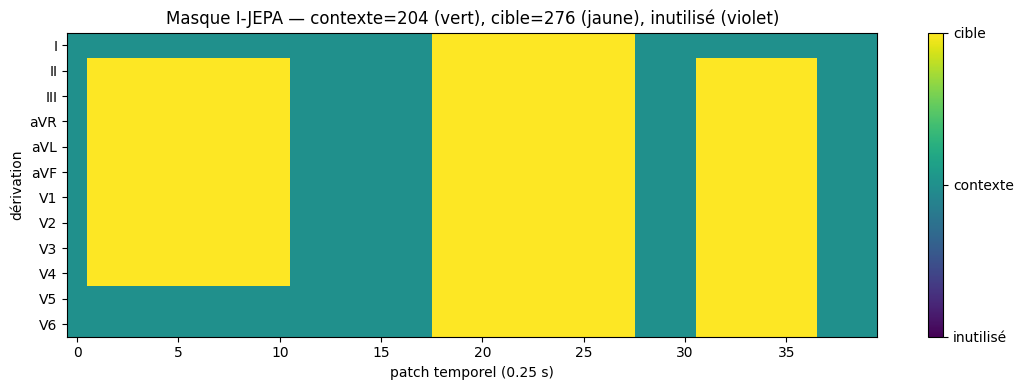

étanchéité OK : contexte ∩ cible = ∅


In [2]:
rng = np.random.default_rng(0)
ctx_idx, tgt_idx = sample_masks(mcfg, rng)

H, W = mcfg.grid_h, mcfg.grid_w
grid = np.zeros(H*W)          # 0=inutilisé, 1=contexte, 2=cible
grid[ctx_idx] = 1
grid[tgt_idx] = 2
grid = grid.reshape(H, W)

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(grid, aspect="auto", cmap="viridis", vmin=0, vmax=2)
ax.set_yticks(range(H)); ax.set_yticklabels(LEADS)
ax.set_xlabel("patch temporel (0.25 s)"); ax.set_ylabel("dérivation")
ax.set_title(f"Masque I-JEPA — contexte={ctx_idx.size} (vert), cible={tgt_idx.size} (jaune), "
             f"inutilisé (violet)")
cbar = fig.colorbar(im, ticks=[0,1,2]); cbar.ax.set_yticklabels(["inutilisé","contexte","cible"])
plt.tight_layout(); plt.show()

assert np.intersect1d(ctx_idx, tgt_idx).size == 0, "contexte et cible doivent être disjoints"
print("étanchéité OK : contexte ∩ cible = ∅")

## 2. Masque projeté sur un vrai ECG

On grise les régions (lead, fenêtre temporelle) qui tombent dans un bloc **cible**
sur quelques dérivations, pour voir ce que le modèle doit prédire.

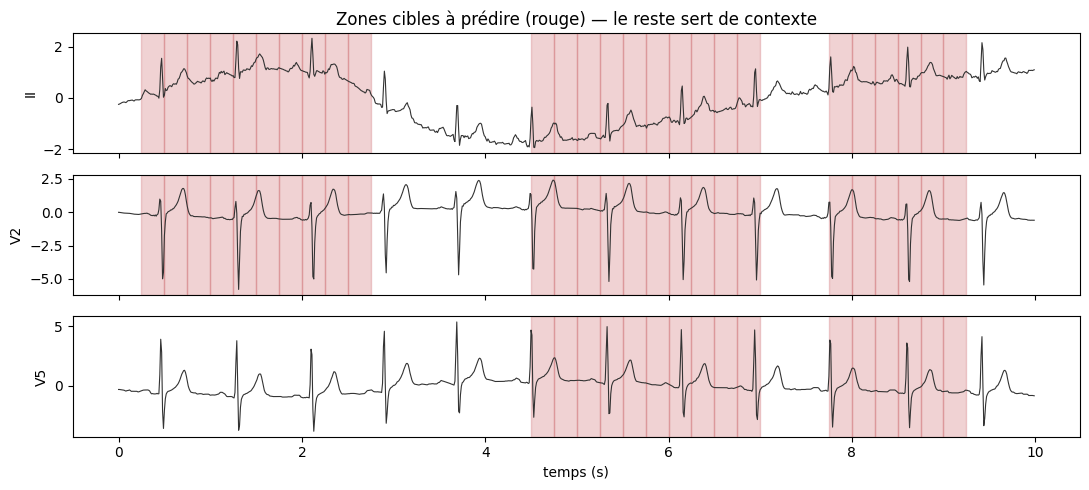

In [3]:
ds = PTBXLDataset("val")                     # repli wfdb si pas de cache
sig = ds[0].numpy()                          # (1000, 12), z-normé
P = model_cfg.patch_len
tgt_grid = np.zeros((H, W), dtype=bool); tgt_grid.reshape(-1)[tgt_idx] = True

show = ["II", "V2", "V5"]
fig, axes = plt.subplots(len(show), 1, figsize=(11, 5), sharex=True)
t = np.arange(1000) / 100
for ax, lead in zip(axes, show):
    li = LEADS.index(lead)
    ax.plot(t, sig[:, li], lw=0.8, color="#333")
    for w in range(W):
        if tgt_grid[li, w]:
            ax.axvspan(w*P/100, (w+1)*P/100, color="#C44E52", alpha=0.25)
    ax.set_ylabel(lead)
axes[-1].set_xlabel("temps (s)")
axes[0].set_title("Zones cibles à prédire (rouge) — le reste sert de contexte")
plt.tight_layout(); plt.show()

## 3. Un pas d'entraînement (forward + backward + métriques collapse)

In [4]:
collate = MaskCollator(mcfg, seed=0)
batch = collate([ds[i] for i in range(8)])

model = JEPA(model_cfg)
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3)

pred, z_tgt, z_ctx = model(batch["signals"], batch["context_idx"], batch["target_idx"])
loss, parts = total_loss(pred, z_tgt, z_ctx)
loss.backward(); opt.step()

print("shapes  pred", tuple(pred.shape), " z_tgt", tuple(z_tgt.shape), " z_ctx", tuple(z_ctx.shape))
print("pertes  ", {k: round(v.item(), 4) for k, v in parts.items()})
print("collapse", {k: round(v, 3) for k, v in collapse_report(z_ctx, z_tgt, pred).items()})

shapes  pred (8, 276, 192)  z_tgt (8, 276, 192)  z_ctx (8, 204, 192)
pertes   {'jepa': 0.4286, 'var': 0.3568, 'cov': 6.9802, 'total': 1.0646}
collapse {'emb_std_ctx': 0.65, 'emb_std_tgt': 0.513, 'pred_std': 0.082, 'eff_rank_ctx': 10.593, 'eff_rank_tgt': 17.752}
